In [2]:
# Installing packages
!pip install watermark
!pip install vaderSentiment
!pip install imbalanced-learn

In [3]:
# Import of libraries

# System libraries
import re
import unicodedata
import itertools
from datasets import Dataset

# Library for file manipulation
import pandas as pd
import numpy as np
import pandas

# Data visualization
import seaborn as sns
import matplotlib.pylab as pl
import matplotlib as m
import matplotlib as mpl
import matplotlib.pyplot as plt
import plotly.express as px
from matplotlib import pyplot as plt

# ML NLP
import nltk
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer

### Download the necessary resources from nltk (tokenizers and stopwords corpus)
# Punkt tokenizer for word tokenization
nltk.download('punkt')

# Stopwords list in multiple languages
nltk.download('stopwords') 

# Configuration for graph width and layout
sns.set_theme(style='whitegrid')
palette='viridis'

# Warnings remove alerts
import warnings
warnings.filterwarnings("ignore")

# Python version
from platform import python_version
print('Python version in this Jupyter Notebook:', python_version())

# Load library versions
import watermark

# Library versions
%reload_ext watermark
%watermark -a "Library versions" --iversions

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\rinka\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\rinka\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


Python version in this Jupyter Notebook: 3.11.5
Author: Library versions

datasets  : 2.12.0
matplotlib: 3.7.2
nltk      : 3.8.1
numpy     : 1.24.3
pandas    : 2.0.3
platform  : 1.0.8
plotly    : 5.9.0
re        : 2.2.1
seaborn   : 0.12.2
watermark : 2.6.0



In [4]:
import pandas as pd

# Database
pd.set_option('display.max_columns', None)
df = pd.read_csv(r"C:\Users\rinka\Desktop\Recommendation\amazon.csv\amazon.csv")

# Viewing dataset
df.head()

,product_id,product_name,category,discounted_price,actual_price,discount_percentage,rating,rating_count,about_product,user_id,user_name,review_id,review_title,review_content,img_link,product_link
0,B07JW9H4J1,Wayona Nylon Braided USB to Lightning Fast Cha...,Computers&Accessories|Accessories&Peripherals|...,₹399,"₹1,099",64%,4.2,"24,269",High Compatibility : Compatible With iPhone 12...,"AG3D6O4STAQKAY2UVGEUV46KN35Q,AHMY5CWJMMK5BJRBB...","Manav,Adarsh gupta,Sundeep,S.Sayeed Ahmed,jasp...","R3HXWT0LRP0NMF,R2AJM3LFTLZHFO,R6AQJGUP6P86,R1K...","Satisfied,Charging is really fast,Value for mo...",Looks durable Charging is fine tooNo complains...,https://m.media-amazon.com/images/W/WEBP_40237...,https://www.amazon.in/Wayona-Braided-WN3LG1-Sy...
1,B098NS6PVG,Ambrane Unbreakable 60W / 3A Fast Charging 1.5...,Computers&Accessories|Accessories&Peripherals|...,₹199,₹349,43%,4.0,"43,994","Compatible with all Type C enabled devices, be...","AECPFYFQVRUWC3KGNLJIOREFP5LQ,AGYYVPDD7YG7FYNBX...","ArdKn,Nirbhay kumar,Sagar Viswanathan,Asp,Plac...","RGIQEG07R9HS2,R1SMWZQ86XIN8U,R2J3Y1WL29GWDE,RY...","A Good Braided Cable for Your Type C Device,Go...",I ordered this cable to connect my phone to An...,https://m.media-amazon.com/images/W/WEBP_40237...,https://www.amazon.in/Ambrane-Unbreakable-Char...
2,B096MSW6CT,Sounce Fast Phone Charging Cable & Data Sync U...,Computers&Accessories|Accessories&Peripherals|...,₹199,"₹1,899",90%,3.9,"7,928",【 Fast Charger& Data Sync】-With built-in safet...,"AGU3BBQ2V2DDAMOAKGFAWDDQ6QHA,AESFLDV2PT363T2AQ...","Kunal,Himanshu,viswanath,sai niharka,saqib mal...","R3J3EQQ9TZI5ZJ,R3E7WBGK7ID0KV,RWU79XKQ6I1QF,R2...","Good speed for earlier versions,Good Product,W...","Not quite durable and sturdy,https://m.media-a...",https://m.media-amazon.com/images/W/WEBP_40237...,https://www.amazon.in/Sounce-iPhone-Charging-C...
3,B08HDJ86NZ,boAt Deuce USB 300 2 in 1 Type-C & Micro USB S...,Computers&Accessories|Accessories&Peripherals|...,₹329,₹699,53%,4.2,"94,363",The boAt Deuce USB 300 2 in 1 cable is compati...,"AEWAZDZZJLQUYVOVGBEUKSLXHQ5A,AG5HTSFRRE6NL3M5S...","Omkar dhale,JD,HEMALATHA,Ajwadh a.,amar singh ...","R3EEUZKKK9J36I,R3HJVYCLYOY554,REDECAZ7AMPQC,R1...","Good product,Good one,Nice,Really nice product...","Good product,long wire,Charges good,Nice,I bou...",https://m.media-amazon.com/images/I/41V5FtEWPk...,https://www.amazon.in/Deuce-300-Resistant-Tang...
4,B08CF3B7N1,Portronics Konnect L 1.2M Fast Charging 3A 8 P...,Computers&Accessories|Accessories&Peripherals|...,₹154,₹399,61%,4.2,"16,905",[CHARGE & SYNC FUNCTION]- This cable comes wit...,"AE3Q6KSUK5P75D5HFYHCRAOLODSA,AFUGIFH5ZAFXRDSZH...","rahuls6099,Swasat Borah,Ajay Wadke,Pranali,RVK...","R1BP4L2HH9TFUP,R16PVJEXKV6QZS,R2UPDB81N66T4P,R...","As good as original,Decent,Good one for second...","Bought this instead of original apple, does th...",https://m.media-amazon.com/images/W/WEBP_40237...,https://www.amazon.in/Portronics-Konnect-POR-1...


In [5]:
print("Checking for missing values in each column:")
print(df.isnull().sum())

Checking for missing values in each column:
product_id             0
product_name           0
category               0
discounted_price       0
actual_price           0
discount_percentage    0
rating                 0
rating_count           2
about_product          0
user_id                0
user_name              0
review_id              0
review_title           0
review_content         0
img_link               0
product_link           0
dtype: int64


In [6]:
# Remove columns that have any NaN value
df = df.dropna(axis=1)

# Check remaining columns after removal
print("Remaining columns after removing columns with NaN:")
print(df.isnull().sum())

Remaining columns after removing columns with NaN:
product_id             0
product_name           0
category               0
discounted_price       0
actual_price           0
discount_percentage    0
rating                 0
about_product          0
user_id                0
user_name              0
review_id              0
review_title           0
review_content         0
img_link               0
product_link           0
dtype: int64


In [7]:
%%time

import re
import string
import nltk
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer

### Download the necessary resources from nltk (tokenizers and stopwords corpus)
# Punkt tokenizer for word tokenization
nltk.download('punkt')
 
# Stopwords list in multiple languages
nltk.download('stopwords')   

# Initialize the Porter stemmer and load English stopwords
stemmer = PorterStemmer()

# Create a set of English stopwords for efficient lookup
stop_words = set(stopwords.words('english'))  

# Function to clean the text by removing URLs, handles, and punctuation
def clean_text(text):
    if isinstance(text, str):
        # Convert text to lowercase
        text = text.lower()

        # Remove URLs (http, https, and www links)
        text = re.sub(r'http\S+|www\S+|https\S+', '', text, flags=re.MULTILINE)

        # Remove markdown-style links [text](link)
        text = re.sub(r'\[.*?\]\(.*?\)', '', text)

        # Remove handles (@username mentions)
        text = re.sub(r'@\w+', '', text)

        # Remove punctuation and special characters
        text = text.translate(str.maketrans('', '', string.punctuation))

        return text
    else:
        return text

# Function to tokenize the text into individual words
def tokenize_text(text):
    if isinstance(text, str):
        return word_tokenize(text)
    else:
        return text

# Function to remove stopwords from the tokenized text
def remove_stopwords(tokens):
    if isinstance(tokens, list):
        return [word for word in tokens if word not in stop_words]
    else:
        return tokens

# Function to apply stemming to the tokens
def stem_tokens(tokens):
    if isinstance(tokens, list):
        return [stemmer.stem(token) for token in tokens]
    else:
        return tokens

### Apply the functions to the DataFrame
# Clean the text
df['Cleaned_Review'] = df['review_content'].apply(clean_text)

# Tokenize the cleaned text
df['Tokenized_Review'] = df['Cleaned_Review'].apply(tokenize_text)

# Apply stemming to the tokenized words
df['Stemmed_Review'] = df['Tokenized_Review'].apply(stem_tokens)  

# Remove stopwords from the tokenized text
df['No_Stopwords_Review'] = df['Tokenized_Review'].apply(remove_stopwords)

# Display the first few rows of the DataFrame to visualize the dataset
df.head()

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\rinka\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\rinka\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


CPU times: total: 15.2 s
Wall time: 15.6 s


,product_id,product_name,category,discounted_price,actual_price,discount_percentage,rating,about_product,user_id,user_name,review_id,review_title,review_content,img_link,product_link,Cleaned_Review,Tokenized_Review,Stemmed_Review,No_Stopwords_Review
0,B07JW9H4J1,Wayona Nylon Braided USB to Lightning Fast Cha...,Computers&Accessories|Accessories&Peripherals|...,₹399,"₹1,099",64%,4.2,High Compatibility : Compatible With iPhone 12...,"AG3D6O4STAQKAY2UVGEUV46KN35Q,AHMY5CWJMMK5BJRBB...","Manav,Adarsh gupta,Sundeep,S.Sayeed Ahmed,jasp...","R3HXWT0LRP0NMF,R2AJM3LFTLZHFO,R6AQJGUP6P86,R1K...","Satisfied,Charging is really fast,Value for mo...",Looks durable Charging is fine tooNo complains...,https://m.media-amazon.com/images/W/WEBP_40237...,https://www.amazon.in/Wayona-Braided-WN3LG1-Sy...,looks durable charging is fine toono complains...,"[looks, durable, charging, is, fine, toono, co...","[look, durabl, charg, is, fine, toono, complai...","[looks, durable, charging, fine, toono, compla..."
1,B098NS6PVG,Ambrane Unbreakable 60W / 3A Fast Charging 1.5...,Computers&Accessories|Accessories&Peripherals|...,₹199,₹349,43%,4.0,"Compatible with all Type C enabled devices, be...","AECPFYFQVRUWC3KGNLJIOREFP5LQ,AGYYVPDD7YG7FYNBX...","ArdKn,Nirbhay kumar,Sagar Viswanathan,Asp,Plac...","RGIQEG07R9HS2,R1SMWZQ86XIN8U,R2J3Y1WL29GWDE,RY...","A Good Braided Cable for Your Type C Device,Go...",I ordered this cable to connect my phone to An...,https://m.media-amazon.com/images/W/WEBP_40237...,https://www.amazon.in/Ambrane-Unbreakable-Char...,i ordered this cable to connect my phone to an...,"[i, ordered, this, cable, to, connect, my, pho...","[i, order, thi, cabl, to, connect, my, phone, ...","[ordered, cable, connect, phone, android, auto..."
2,B096MSW6CT,Sounce Fast Phone Charging Cable & Data Sync U...,Computers&Accessories|Accessories&Peripherals|...,₹199,"₹1,899",90%,3.9,【 Fast Charger& Data Sync】-With built-in safet...,"AGU3BBQ2V2DDAMOAKGFAWDDQ6QHA,AESFLDV2PT363T2AQ...","Kunal,Himanshu,viswanath,sai niharka,saqib mal...","R3J3EQQ9TZI5ZJ,R3E7WBGK7ID0KV,RWU79XKQ6I1QF,R2...","Good speed for earlier versions,Good Product,W...","Not quite durable and sturdy,https://m.media-a...",https://m.media-amazon.com/images/W/WEBP_40237...,https://www.amazon.in/Sounce-iPhone-Charging-C...,not quite durable and sturdy good nice product...,"[not, quite, durable, and, sturdy, good, nice,...","[not, quit, durabl, and, sturdi, good, nice, p...","[quite, durable, sturdy, good, nice, productwo..."
3,B08HDJ86NZ,boAt Deuce USB 300 2 in 1 Type-C & Micro USB S...,Computers&Accessories|Accessories&Peripherals|...,₹329,₹699,53%,4.2,The boAt Deuce USB 300 2 in 1 cable is compati...,"AEWAZDZZJLQUYVOVGBEUKSLXHQ5A,AG5HTSFRRE6NL3M5S...","Omkar dhale,JD,HEMALATHA,Ajwadh a.,amar singh ...","R3EEUZKKK9J36I,R3HJVYCLYOY554,REDECAZ7AMPQC,R1...","Good product,Good one,Nice,Really nice product...","Good product,long wire,Charges good,Nice,I bou...",https://m.media-amazon.com/images/I/41V5FtEWPk...,https://www.amazon.in/Deuce-300-Resistant-Tang...,good productlong wirecharges goodnicei bought ...,"[good, productlong, wirecharges, goodnicei, bo...","[good, productlong, wirecharg, goodnicei, boug...","[good, productlong, wirecharges, goodnicei, bo..."
4,B08CF3B7N1,Portronics Konnect L 1.2M Fast Charging 3A 8 P...,Computers&Accessories|Accessories&Peripherals|...,₹154,₹399,61%,4.2,[CHARGE & SYNC FUNCTION]- This cable comes wit...,"AE3Q6KSUK5P75D5HFYHCRAOLODSA,AFUGIFH5ZAFXRDSZH...","rahuls6099,Swasat Borah,Ajay Wadke,Pranali,RVK...","R1BP4L2HH9TFUP,R16PVJEXKV6QZS,R2UPDB81N66T4P,R...","As good as original,Decent,Good one for second...","Bought this instead of original apple, does th...",https://m.media-amazon.com/images/W/WEBP_40237...,https://www.amazon.in/Portronics-Konnect-POR-1...,bought this instead of original apple does the...,"[bought, this, instead, of, original, apple, d...","[bought, thi, instead, of, origin, appl, doe, ...","[bought, instead, original, apple, work, 150rs..."


In [8]:
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

# Create an instance of SentimentIntensityAnalyzer, which is part of the VADER sentiment analysis tool.
analyzer = SentimentIntensityAnalyzer()

# Function to apply VADER sentiment analysis to each review.
# The function takes in a 'review' (text) and returns the polarity scores, which include
# 'compound', 'positive', 'negative', and 'neutral' sentiment values.
def get_sentiment(review):
    return analyzer.polarity_scores(review)

# Apply the 'get_sentiment' function to each entry in the 'Cleaned_Review' column.
# Store the resulting sentiment scores (dictionary) in a new column 'vader_scores'.
df['vader_scores'] = df['Cleaned_Review'].apply(get_sentiment)

# Extract the 'compound' score from the 'vader_scores' dictionary for each review.
# The 'compound' score is a normalized score ranging from -1 (most negative) to +1 (most positive),
# summarizing the overall sentiment of the text.
df['compound'] = df['vader_scores'].apply(lambda score_dict: score_dict['compound'])

# Function to classify the sentiment based on the 'compound' score.
# Scores >= 0.05 are classified as 'Positive', <= -0.05 as 'Negative', and anything in between as 'Neutral'.
def classify_sentiment(compound_score):
    if compound_score >= 0.05:
        return 'Positive'
    elif compound_score <= -0.05:
        return 'Negative'
    else:
        return 'Neutral'

# Apply the 'classify_sentiment' function to the 'compound' score to get the overall sentiment
# classification (Positive, Negative, or Neutral) for each review.
df['sentiment'] = df['compound'].apply(classify_sentiment)

# Display the first few rows of the DataFrame, showing the cleaned review text,
# the 'compound' sentiment score, and the classified 'sentiment'.
print(df[['Cleaned_Review', 'compound', 'sentiment']].head(10))

                                      Cleaned_Review  compound sentiment
0  looks durable charging is fine toono complains...    0.9243  Positive
1  i ordered this cable to connect my phone to an...    0.9816  Positive
2  not quite durable and sturdy good nice product...    0.8313  Positive
3  good productlong wirecharges goodnicei bought ...    0.8316  Positive
4  bought this instead of original apple does the...    0.9957  Positive
5  its a good productlikevery good item strong an...    0.6611  Positive
6  build quality is good and it is comes with 2 y...    0.8735  Positive
7  worth for money  suitable for android auto my ...    0.9334  Positive
8  i use this to connect an old pc to internet i ...    0.9889  Positive
9  i ordered this cable to connect my phone to an...    0.9816  Positive


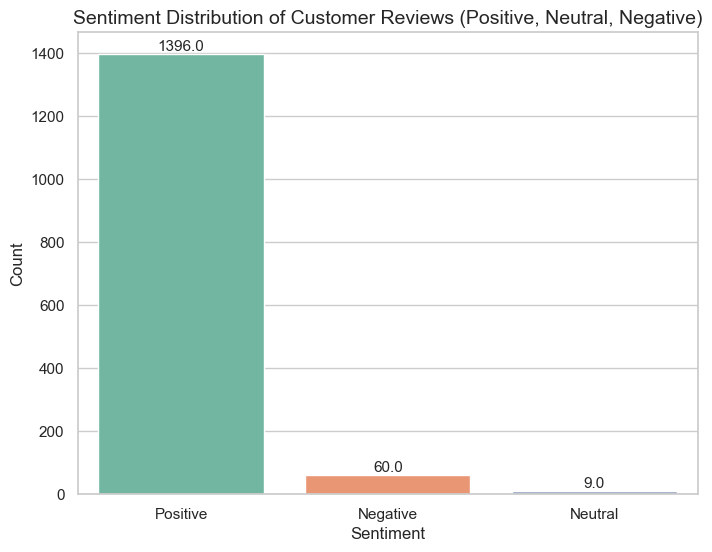

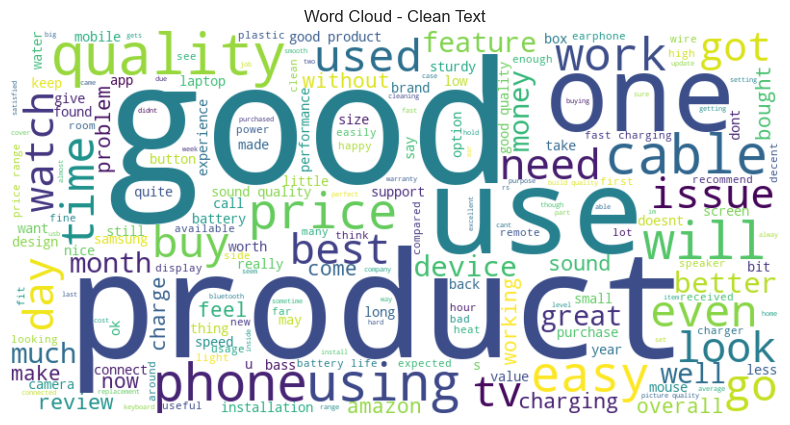

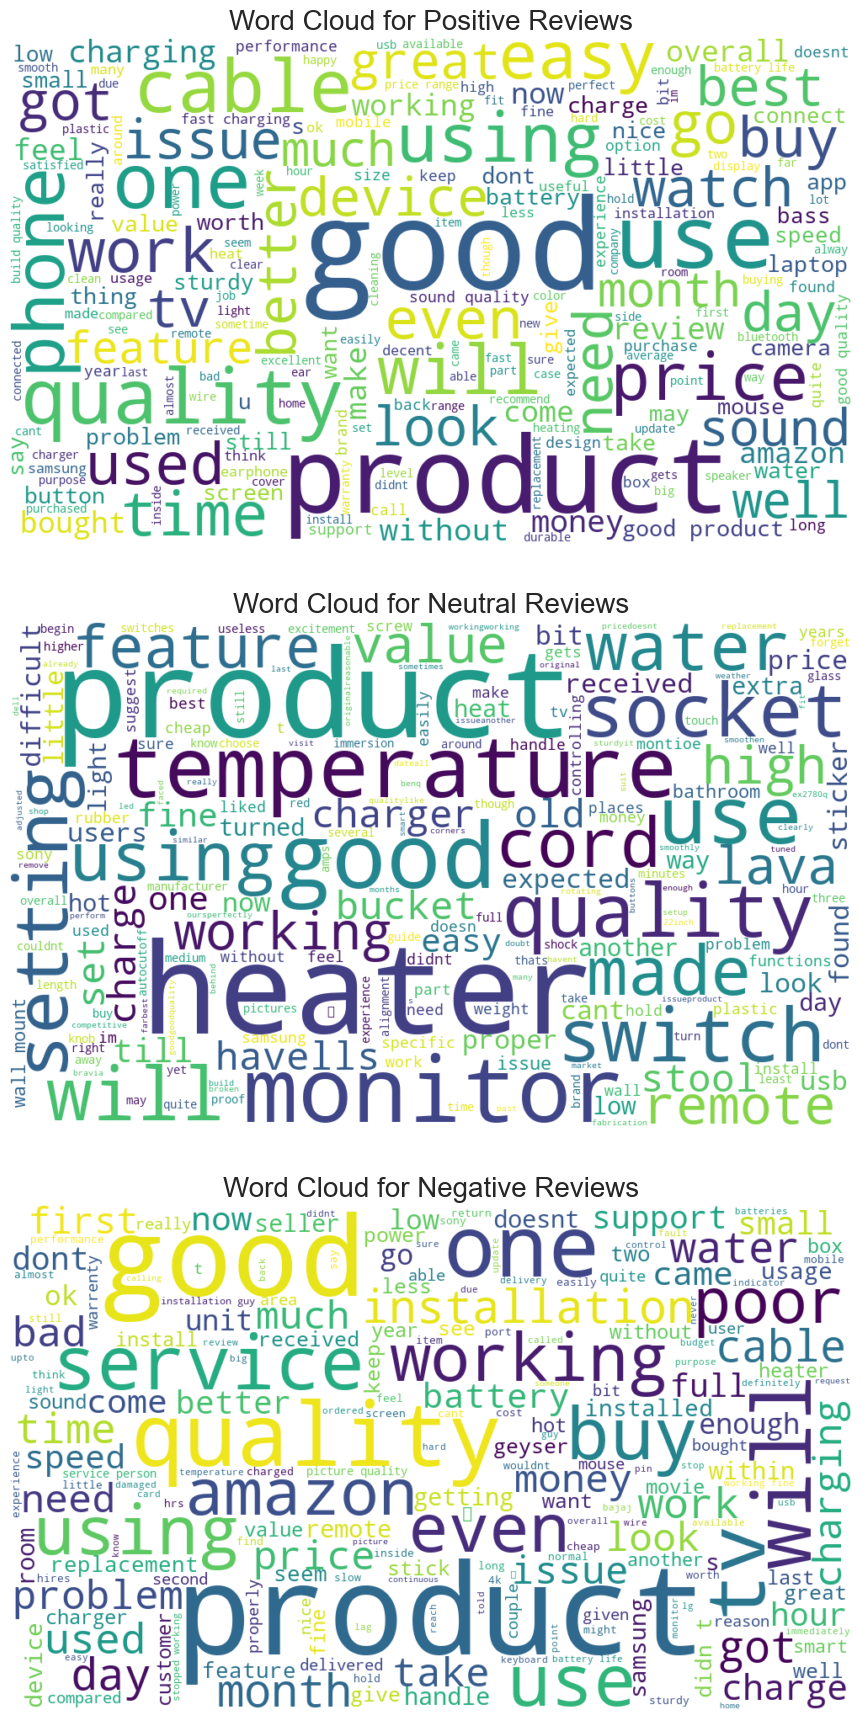

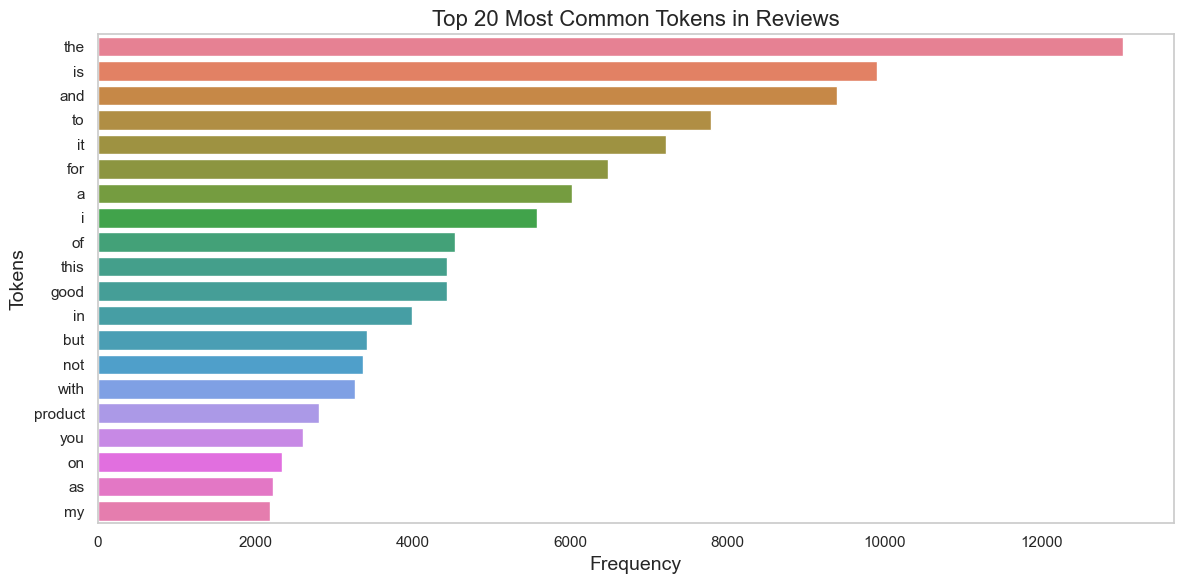

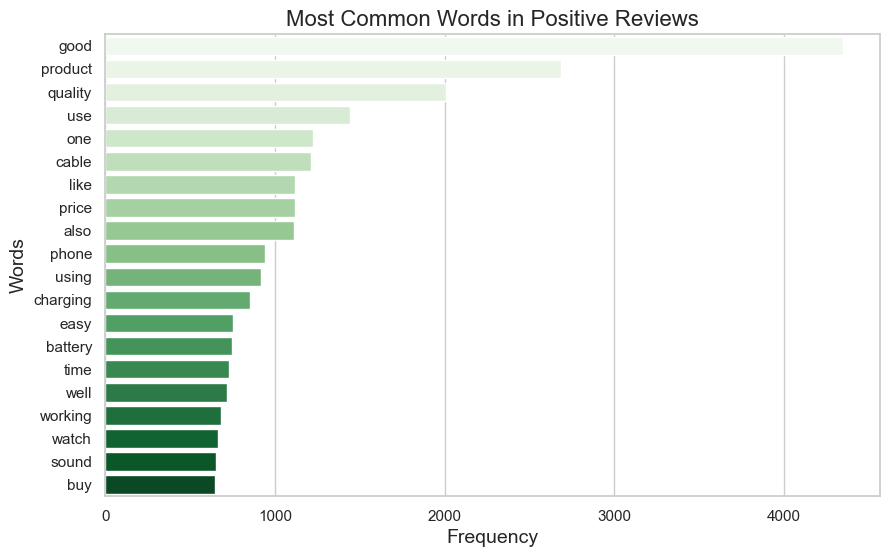

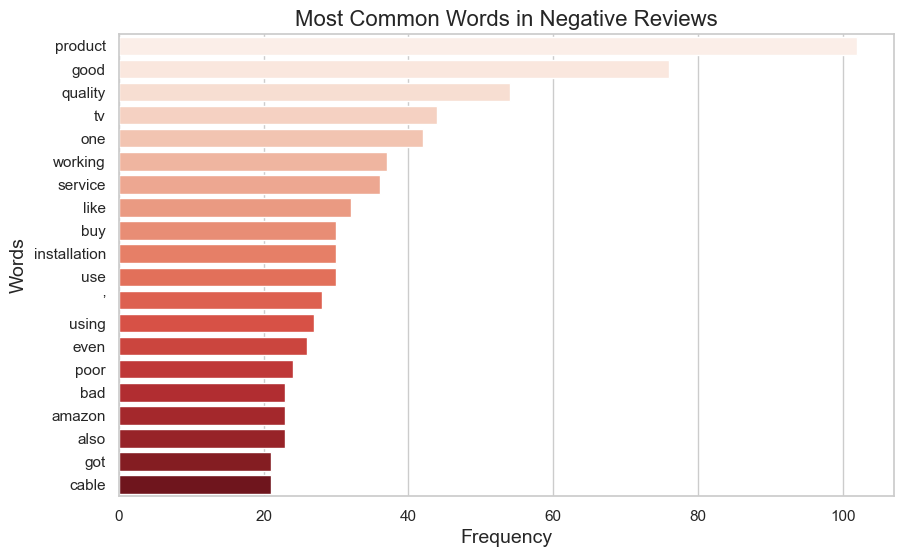

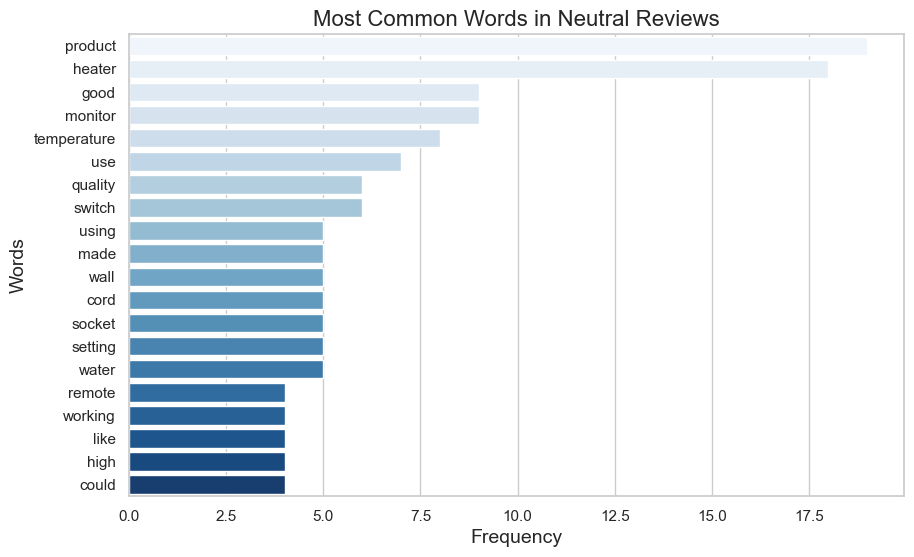

In [9]:
# Assuming df is already loaded and contains the 'sentiment' column
plt.figure(figsize=(8, 6))

# Count plot with a specific color palette
sns.countplot(data=df, x='sentiment', palette='Set2')

# Add title and axis labels with adjusted font sizes
plt.title('Sentiment Distribution of Customer Reviews (Positive, Neutral, Negative)', fontsize=14)
plt.xlabel('Sentiment', fontsize=12)
plt.ylabel('Count', fontsize=12)

# Adding data labels on top of the bars
for p in plt.gca().patches:
    plt.gca().annotate(f'{p.get_height()}', (p.get_x() + p.get_width() / 2, p.get_height()), 
                       ha='center', va='bottom', fontsize=11)

# Display the plot
plt.show()

#################################################################################################
from wordcloud import WordCloud

wordcloud = WordCloud(width=800, height=400, 
                      background_color='white').generate(' '.join(df['Cleaned_Review'].dropna()))
plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title("Word Cloud - Clean Text")
plt.show()

#################################################################################################

# Separate reviews based on sentiment
positive_reviews = " ".join(df[df['sentiment'] == 'Positive']['Cleaned_Review'].tolist())
neutral_reviews = " ".join(df[df['sentiment'] == 'Neutral']['Cleaned_Review'].tolist())
negative_reviews = " ".join(df[df['sentiment'] == 'Negative']['Cleaned_Review'].tolist())

# Generate word clouds with larger dimensions and font size
wordcloud_positive = WordCloud(width=1000, height=600, background_color='white', max_font_size=150).generate(positive_reviews)
wordcloud_neutral = WordCloud(width=1000, height=600, background_color='white', max_font_size=150).generate(neutral_reviews)
wordcloud_negative = WordCloud(width=1000, height=600, background_color='white', max_font_size=150).generate(negative_reviews)

# Plot the word clouds for each sentiment with larger figure size
plt.figure(figsize=(10, 18))

# Positive word cloud
plt.subplot(3, 1, 1)
plt.imshow(wordcloud_positive, interpolation='bilinear')
plt.title('Word Cloud for Positive Reviews', fontsize=20)
plt.axis('off')

# Neutral word cloud
plt.subplot(3, 1, 2)
plt.imshow(wordcloud_neutral, interpolation='bilinear')
plt.title('Word Cloud for Neutral Reviews', fontsize=20)
plt.axis('off')

# Negative word cloud
plt.subplot(3, 1, 3)
plt.imshow(wordcloud_negative, interpolation='bilinear')
plt.title('Word Cloud for Negative Reviews', fontsize=20)
plt.axis('off')

# Show the word clouds
plt.tight_layout(pad=3)
plt.show()

######################################################################################################

from collections import Counter

# Combine all tokens into a single list
all_tokens = [token for tokens in df['Tokenized_Review'] for token in tokens]

# Count the frequency of tokens
token_counts = Counter(all_tokens)

# Get the top 20 most common tokens
common_tokens = token_counts.most_common(20)  # Limiting to top 20

# Separate tokens and their frequencies
tokens, frequencies = zip(*common_tokens)

# Create a bar plot for the most frequent tokens
plt.figure(figsize=(12, 6))
sns.barplot(x=list(frequencies), y=list(tokens), palette='husl')  # Changed palette

# Improved title and axis labels
plt.title('Top 20 Most Common Tokens in Reviews', fontsize=16)
plt.xlabel('Frequency', fontsize=14)
plt.ylabel('Tokens', fontsize=14)

# Add gridlines for easier reading of bar heights
plt.grid(axis='x', linestyle='--', alpha=0.7)

# Display the plot
plt.tight_layout()  # Ensure layout is clean and labels fit well
plt.grid(False)
plt.show()

#################################################################################################

from collections import Counter

# Function to plot the most common words for each sentiment
def plot_most_common_words(common_words, sentiment, color):
    # Unzip the common_words tuple into two lists: words and their respective counts
    words, counts = zip(*common_words)
    
    # Create a bar chart
    plt.figure(figsize=(10, 6))
    sns.barplot(x=list(counts), y=list(words), palette=color)
    
    # Set the title and axis labels
    plt.title(f'Most Common Words in {sentiment} Reviews', fontsize=16)
    plt.xlabel('Frequency', fontsize=14)
    plt.ylabel('Words', fontsize=14)
    
    # Display the chart
    plt.show()

# Generate the most common words for each sentiment

# Filter reviews based on sentiment
positive_reviews = df[df['sentiment'] == 'Positive']['No_Stopwords_Review']
negative_reviews = df[df['sentiment'] == 'Negative']['No_Stopwords_Review']
neutral_reviews = df[df['sentiment'] == 'Neutral']['No_Stopwords_Review']

# Combine all words into a single list for each sentiment
positive_words_list = [word for review in positive_reviews for word in review]
negative_words_list = [word for review in negative_reviews for word in review]
neutral_words_list = [word for review in neutral_reviews for word in review]

# Count the most common words in each sentiment's word list
positive_words = Counter(positive_words_list).most_common(20)
negative_words = Counter(negative_words_list).most_common(20)
neutral_words = Counter(neutral_words_list).most_common(20)

# Plot the most common words for Positive sentiment
plot_most_common_words(positive_words, 'Positive', 'Greens')

# Plot the most common words for Negative sentiment
plot_most_common_words(negative_words, 'Negative', 'Reds')

# Plot the most common words for Neutral sentiment
plot_most_common_words(neutral_words, 'Neutral', 'Blues')

In [22]:
# Deleting unwanted columns
#reviews.text	Cleaned_Review	Tokenized_Review	Stemmed_Review	No_Stopwords_Review	compound	sentiment

df = df.drop(columns=["img_link","product_link",])
# Displaying the first few rows of the dataframe to verify
df.head()

,review_content,Cleaned_Review,Tokenized_Review,Stemmed_Review,No_Stopwords_Review,compound,sentiment
0,Looks durable Charging is fine tooNo complains...,looks durable charging is fine toono complains...,"[looks, durable, charging, is, fine, toono, co...","[look, durabl, charg, is, fine, toono, complai...","[looks, durable, charging, fine, toono, compla...",0.9243,Positive
1,I ordered this cable to connect my phone to An...,i ordered this cable to connect my phone to an...,"[i, ordered, this, cable, to, connect, my, pho...","[i, order, thi, cabl, to, connect, my, phone, ...","[ordered, cable, connect, phone, android, auto...",0.9816,Positive
2,"Not quite durable and sturdy,https://m.media-a...",not quite durable and sturdy good nice product...,"[not, quite, durable, and, sturdy, good, nice,...","[not, quit, durabl, and, sturdi, good, nice, p...","[quite, durable, sturdy, good, nice, productwo...",0.8313,Positive
3,"Good product,long wire,Charges good,Nice,I bou...",good productlong wirecharges goodnicei bought ...,"[good, productlong, wirecharges, goodnicei, bo...","[good, productlong, wirecharg, goodnicei, boug...","[good, productlong, wirecharges, goodnicei, bo...",0.8316,Positive
4,"Bought this instead of original apple, does th...",bought this instead of original apple does the...,"[bought, this, instead, of, original, apple, d...","[bought, thi, instead, of, origin, appl, doe, ...","[bought, instead, original, apple, work, 150rs...",0.9957,Positive


In [23]:
from sklearn.feature_extraction.text import TfidfVectorizer

# Step 1: Convert text data into numerical features using TF-IDF
tfidf_vectorizer = TfidfVectorizer(max_features=5000)  # Limiting to top 5000 features

# Training and testing division
X = tfidf_vectorizer.fit_transform(df['Cleaned_Review'])
y = df['sentiment']

tfidf_vectorizer

TfidfVectorizer(max_features=5000)

In [24]:
# Visualizing data x
X.shape

(1465, 5000)

In [25]:
# Viewing y data
y.shape

(1465,)

In [26]:
# Import the LabelEncoder class from sklearn, which is used to convert categorical labels to numeric values
from sklearn.preprocessing import LabelEncoder

# Initialize the LabelEncoder instance
le = LabelEncoder()

# Apply LabelEncoder to the target variable 'y', which contains categorical sentiment labels
# The fit_transform() method encodes the labels (e.g., 'Positive', 'Neutral', 'Negative') into numeric values (e.g., 0, 1, 2)
y = le.fit_transform(y)

# The 'le' object now contains the mapping between the original labels and the numeric values
le

LabelEncoder()

In [27]:
# Importing library
from sklearn.model_selection import train_test_split

# Training and testing division
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Viewing training data
print("Viewing rows and columns given by X train", X_train.shape)

# Viewing test data
print("Viewing rows and columns given y train", y_train.shape)

Viewing rows and columns given by X train (1172, 5000)
Viewing rows and columns given y train (1172,)


In [28]:
# Convert your TF-IDF sparse matrix to a dense matrix
X_train_dense = X_train.toarray()
X_test_dense = X_test.toarray()

In [35]:
# Importing libraries
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier, GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier

# Models to be evaluated
models = [ 
            # Naive Bayes Model (requires dense matrix)
            GaussianNB(),
    
            # Decision Tree Model
            DecisionTreeClassifier(random_state=42),
    
            # Random forest model
            RandomForestClassifier(n_estimators=100, random_state=42),
    
            # Logistic regression model
            LogisticRegression(random_state=50),
    
            # Ada Boost Model
            AdaBoostClassifier(random_state=45),
    
            # XGBoost Model (can use sparse matrix)
            XGBClassifier(tree_method='hist', random_state=42),
    
            # LightGBM Model (can use sparse matrix)
            LGBMClassifier(num_leaves=31,
                           boosting_type='gbdt',
                           bagging_fraction=0.9,
                           learning_rate=0.05,
                           feature_fraction=0.9,
                           bagging_freq=50,
                           verbose=50,
                           device='gpu'),
    
            # K-Nearest Neighbors Model
            KNeighborsClassifier(n_neighbors=13), 
    
            # Gradient Boosting Classifier
            GradientBoostingClassifier(random_state=42)]

# Evaluate each model
for i, model in enumerate(models):
    # For GaussianNB (requires dense matrix)
    if isinstance(model, GaussianNB):
        model.fit(X_train_dense, y_train)
        train_accuracy = accuracy_score(y_train, model.predict(X_train_dense))
        test_accuracy = accuracy_score(y_test, model.predict(X_test_dense))
    else:
        # For all other models
        model.fit(X_train, y_train)
        train_accuracy = accuracy_score(y_train, model.predict(X_train))
        test_accuracy = accuracy_score(y_test, model.predict(X_test))

    print(f"Model {i+1}: {type(model).__name__}")
    print(f"Training Accuracy: {train_accuracy:.4f}")
    print(f"Testing Accuracy: {test_accuracy:.4f}")
    print("-----------------")

Model 1: GaussianNB
Training Accuracy: 0.9983
Testing Accuracy: 0.9488
-----------------
Model 2: DecisionTreeClassifier
Training Accuracy: 1.0000
Testing Accuracy: 0.9147
-----------------
Model 3: RandomForestClassifier
Training Accuracy: 1.0000
Testing Accuracy: 0.9522
-----------------
Model 4: LogisticRegression
Training Accuracy: 0.9556
Testing Accuracy: 0.9522
-----------------
Model 5: AdaBoostClassifier
Training Accuracy: 0.9582
Testing Accuracy: 0.9454
-----------------
Model 6: XGBClassifier
Training Accuracy: 1.0000
Testing Accuracy: 0.9522
-----------------
[LightGBM] [Warning] feature_fraction is set=0.9, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.9
[LightGBM] [Warning] bagging_fraction is set=0.9, subsample=1.0 will be ignored. Current value: bagging_fraction=0.9
[LightGBM] [Warning] bagging_freq is set=50, subsample_freq=0 will be ignored. Current value: bagging_freq=50
[LightGBM] [Warning] feature_fraction is set=0.9, colsample_bytree=1.0 w

[LightGBM] [Debug] Trained a tree with leaves = 31 and depth = 12
[LightGBM] [Debug] Trained a tree with leaves = 31 and depth = 12
[LightGBM] [Debug] Trained a tree with leaves = 31 and depth = 9
[LightGBM] [Debug] Trained a tree with leaves = 31 and depth = 9
[LightGBM] [Debug] Trained a tree with leaves = 31 and depth = 11
[LightGBM] [Debug] Trained a tree with leaves = 31 and depth = 15
[LightGBM] [Debug] Trained a tree with leaves = 31 and depth = 8
[LightGBM] [Debug] Trained a tree with leaves = 31 and depth = 11
[LightGBM] [Debug] Trained a tree with leaves = 31 and depth = 11
[LightGBM] [Debug] Trained a tree with leaves = 31 and depth = 9
[LightGBM] [Debug] Trained a tree with leaves = 31 and depth = 11
[LightGBM] [Debug] Trained a tree with leaves = 31 and depth = 10
[LightGBM] [Debug] Trained a tree with leaves = 31 and depth = 8
[LightGBM] [Debug] Trained a tree with leaves = 31 and depth = 10
[LightGBM] [Debug] Trained a tree with leaves = 31 and depth = 13
[LightGBM] [Deb

[LightGBM] [Debug] Trained a tree with leaves = 31 and depth = 13
[LightGBM] [Debug] Trained a tree with leaves = 31 and depth = 9
[LightGBM] [Debug] Trained a tree with leaves = 31 and depth = 10
[LightGBM] [Debug] Trained a tree with leaves = 31 and depth = 13
[LightGBM] [Debug] Trained a tree with leaves = 31 and depth = 9
[LightGBM] [Debug] Trained a tree with leaves = 31 and depth = 9
[LightGBM] [Debug] Trained a tree with leaves = 31 and depth = 8
[LightGBM] [Debug] Trained a tree with leaves = 31 and depth = 10
[LightGBM] [Debug] Trained a tree with leaves = 31 and depth = 9
[LightGBM] [Debug] Trained a tree with leaves = 31 and depth = 10
[LightGBM] [Debug] Trained a tree with leaves = 31 and depth = 9
[LightGBM] [Debug] Trained a tree with leaves = 31 and depth = 10
[LightGBM] [Debug] Trained a tree with leaves = 31 and depth = 11
[LightGBM] [Debug] Trained a tree with leaves = 31 and depth = 8
[LightGBM] [Debug] Trained a tree with leaves = 31 and depth = 10
[LightGBM] [Debug

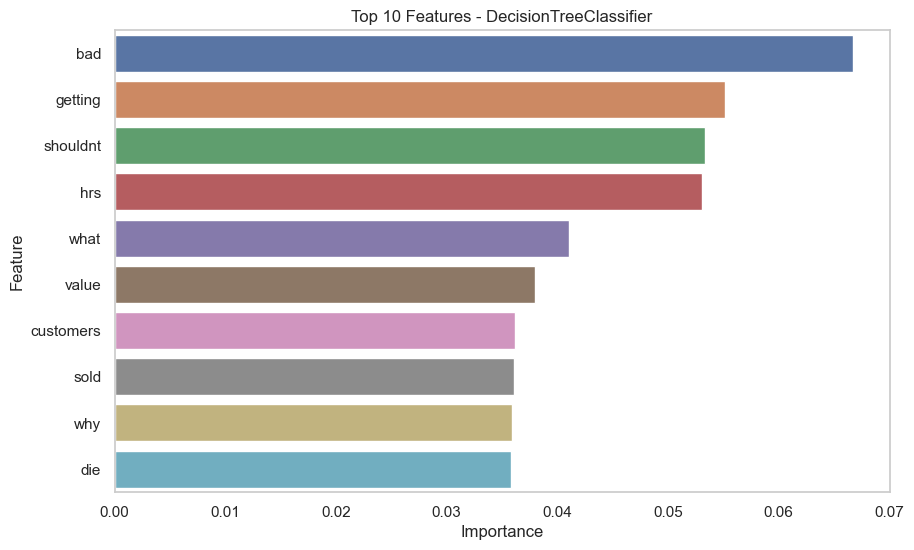

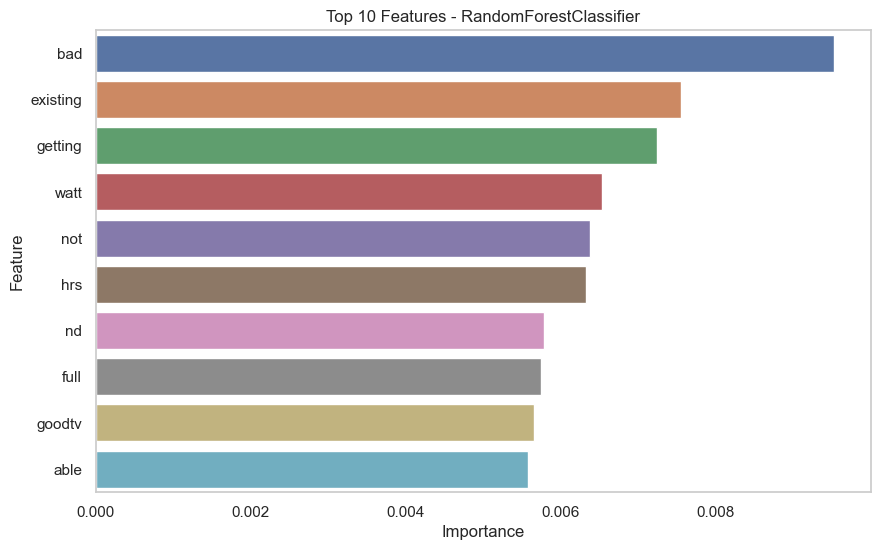

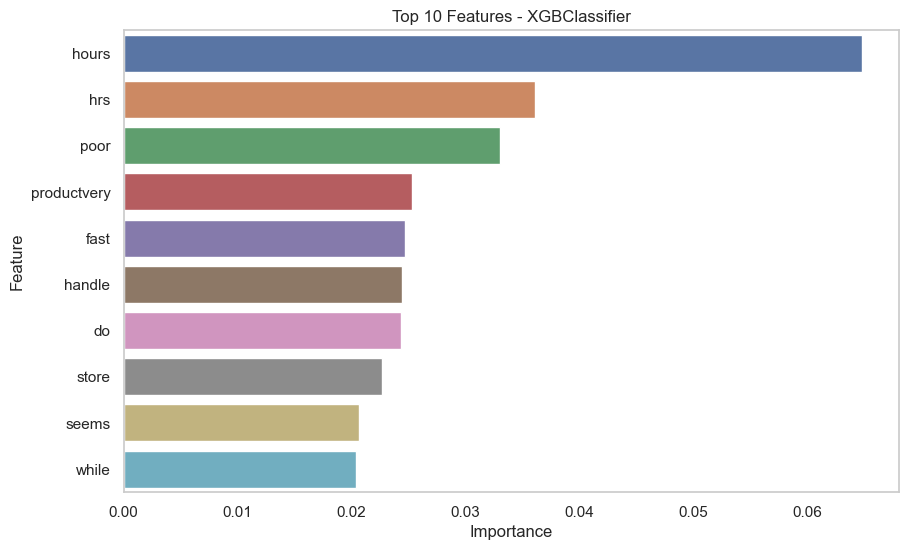

[LightGBM] [Debug] Dataset::GetMultiBinFromSparseFeatures: sparse rate 0.938296
[LightGBM] [Debug] Dataset::GetMultiBinFromAllFeatures: sparse rate 0.920422
[LightGBM] [Debug] init for col-wise cost 0.018721 seconds, init for row-wise cost 0.011480 seconds
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.021409 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Debug] Using Sparse Multi-Val Bin
[LightGBM] [Info] Total Bins 32999
[LightGBM] [Info] Number of data points in the train set: 1172, number of used features: 1117
[LightGBM] [Info] Start training from score -3.174647
[LightGBM] [Info] Start training from score -5.274708
[LightGBM] [Info] Start training from score -0.048065
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Debug] Trained a tree with leaves = 12 and depth = 10
[LightGBM] [Warning] No further splits 

[LightGBM] [Debug] Trained a tree with leaves = 31 and depth = 10
[LightGBM] [Debug] Trained a tree with leaves = 31 and depth = 14
[LightGBM] [Debug] Trained a tree with leaves = 31 and depth = 15
[LightGBM] [Debug] Trained a tree with leaves = 31 and depth = 10
[LightGBM] [Debug] Trained a tree with leaves = 31 and depth = 12
[LightGBM] [Debug] Trained a tree with leaves = 31 and depth = 15
[LightGBM] [Debug] Trained a tree with leaves = 31 and depth = 10
[LightGBM] [Debug] Trained a tree with leaves = 31 and depth = 15
[LightGBM] [Debug] Trained a tree with leaves = 31 and depth = 17
[LightGBM] [Debug] Trained a tree with leaves = 31 and depth = 10
[LightGBM] [Debug] Trained a tree with leaves = 31 and depth = 10
[LightGBM] [Debug] Trained a tree with leaves = 31 and depth = 16
[LightGBM] [Debug] Trained a tree with leaves = 31 and depth = 11
[LightGBM] [Debug] Trained a tree with leaves = 31 and depth = 12
[LightGBM] [Debug] Trained a tree with leaves = 31 and depth = 11
[LightGBM]

[LightGBM] [Debug] Trained a tree with leaves = 31 and depth = 14
[LightGBM] [Debug] Trained a tree with leaves = 31 and depth = 12
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Debug] Trained a tree with leaves = 7 and depth = 4
[LightGBM] [Debug] Trained a tree with leaves = 31 and depth = 14
[LightGBM] [Debug] Trained a tree with leaves = 31 and depth = 12
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Debug] Trained a tree with leaves = 6 and depth = 4
[LightGBM] [Debug] Trained a tree with leaves = 31 and depth = 14
[LightGBM] [Debug] Trained a tree with leaves = 31 and depth = 12
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Debug] Trained a tree with leaves = 6 and depth = 4
[LightGBM] [Debug] Trained a tree with leaves = 31 and depth = 12
[LightGBM] [Debug] Trained a tree with leaves = 31 and depth = 14
[LightGBM] [Warning] No further splits with positive ga

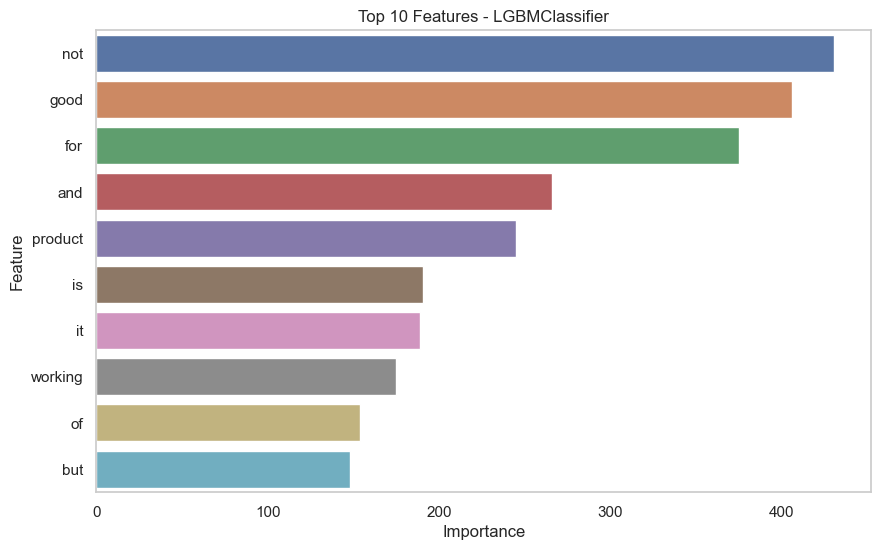

In [36]:
# Train models that support feature importances
models_with_feature_importances = [("DecisionTreeClassifier", DecisionTreeClassifier(random_state=42)),
                                   ("RandomForestClassifier", RandomForestClassifier(n_estimators=100, random_state=42)),
                                   ("XGBClassifier", XGBClassifier(random_state=42)),
                                   ("LGBMClassifier", LGBMClassifier(random_state=42))]

# Get feature names from the TfidfVectorizer
feature_names = tfidf_vectorizer.get_feature_names_out()

# Iterate over models
for model_name, model in models_with_feature_importances:
    
    # Train model
    model.fit(X_train, y_train)
    
    # Get importance of features
    if hasattr(model, 'feature_importances_'):
        feature_importances = model.feature_importances_
    else:
        # If the model does not have feature_importances_, continue to the next model
        print(f"{model_name} does not support feature importances.")
        continue

    # Create DataFrame for easier viewing
    feature_importances_df = pd.DataFrame({'Feature': feature_names, 
                                           'Importance': feature_importances})
    
    # Sort by importance
    feature_importances_df = feature_importances_df.sort_values(by='Importance', ascending=False)
    
    # Plot
    plt.figure(figsize=(10, 6))
    sns.barplot(x='Importance', y='Feature', data=feature_importances_df[:10])
    plt.title(f"Top 10 Features - {model_name}")
    plt.xlabel('Importance')
    plt.ylabel('Feature')
    plt.grid(False)
    plt.show()

Model 1: GaussianNB
Training Accuracy: 0.9982935153583617
Testing Accuracy: 0.9488054607508533

Confusion matrix for Model 1: GaussianNB 

 [[  0   0  11]
 [  0   0   3]
 [  0   1 278]]


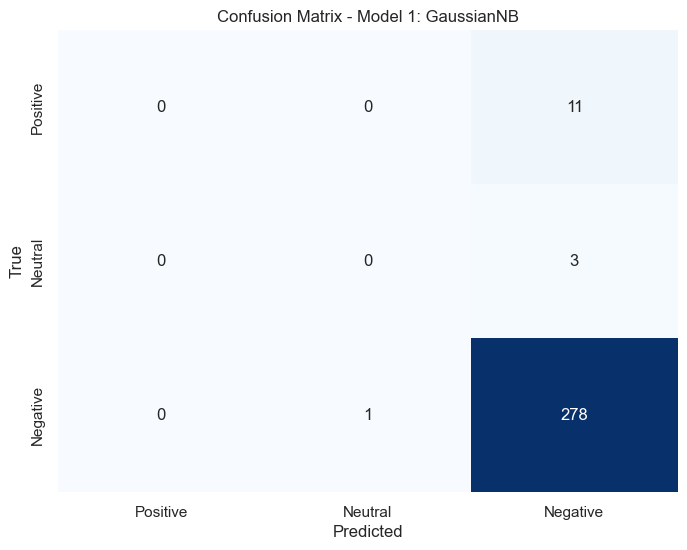

------------------
Model 2: DecisionTreeClassifier
Training Accuracy: 1.0
Testing Accuracy: 0.9146757679180887

Confusion matrix for Model 2: DecisionTreeClassifier 

 [[  2   0   9]
 [  0   0   3]
 [ 12   1 266]]


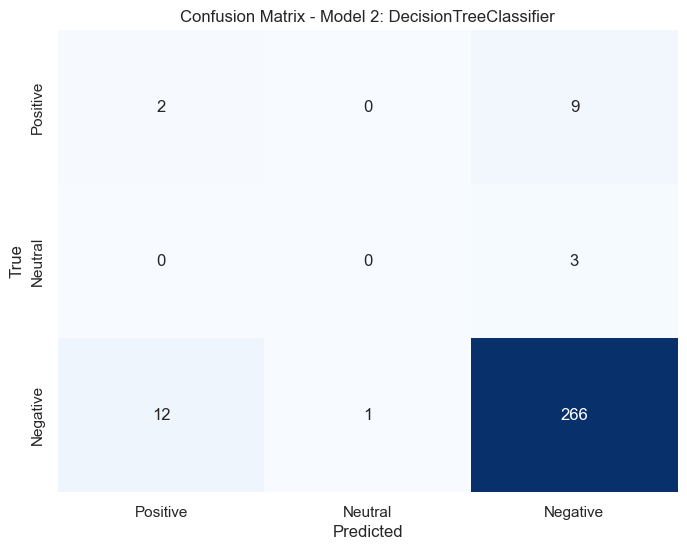

------------------
Model 3: RandomForestClassifier
Training Accuracy: 1.0
Testing Accuracy: 0.9522184300341296

Confusion matrix for Model 3: RandomForestClassifier 

 [[  0   0  11]
 [  0   0   3]
 [  0   0 279]]


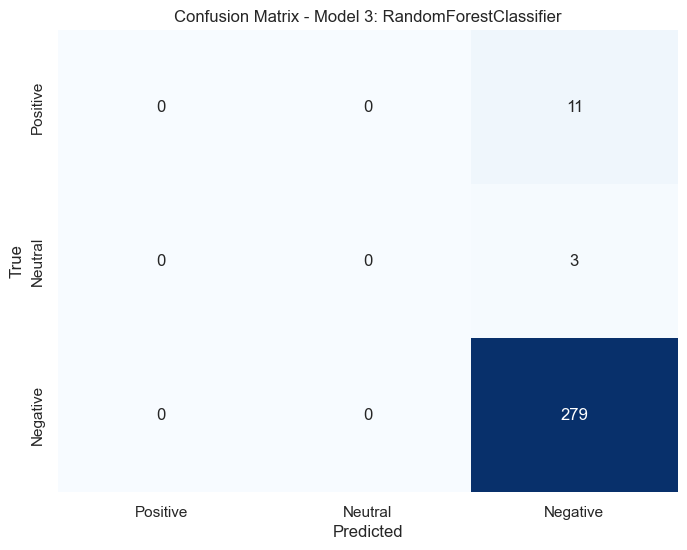

------------------
Model 4: LogisticRegression
Training Accuracy: 0.9556313993174061
Testing Accuracy: 0.9522184300341296

Confusion matrix for Model 4: LogisticRegression 

 [[  0   0  11]
 [  0   0   3]
 [  0   0 279]]


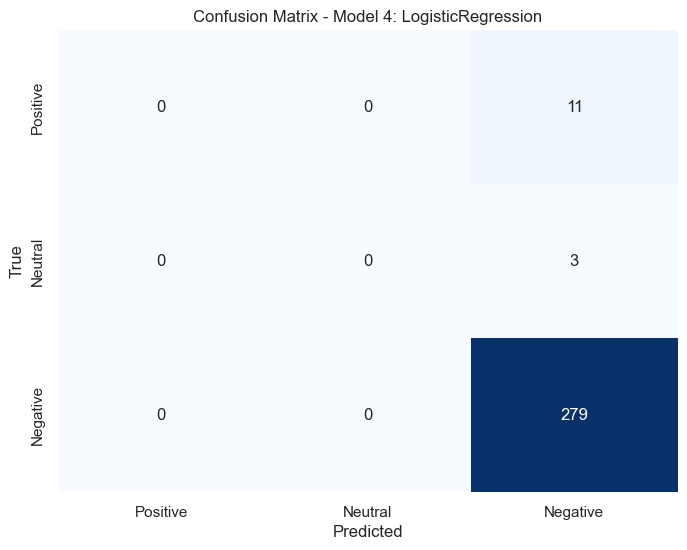

------------------
Model 5: AdaBoostClassifier
Training Accuracy: 0.9581911262798635
Testing Accuracy: 0.9453924914675768

Confusion matrix for Model 5: AdaBoostClassifier 

 [[  0   0  11]
 [  0   0   3]
 [  2   0 277]]


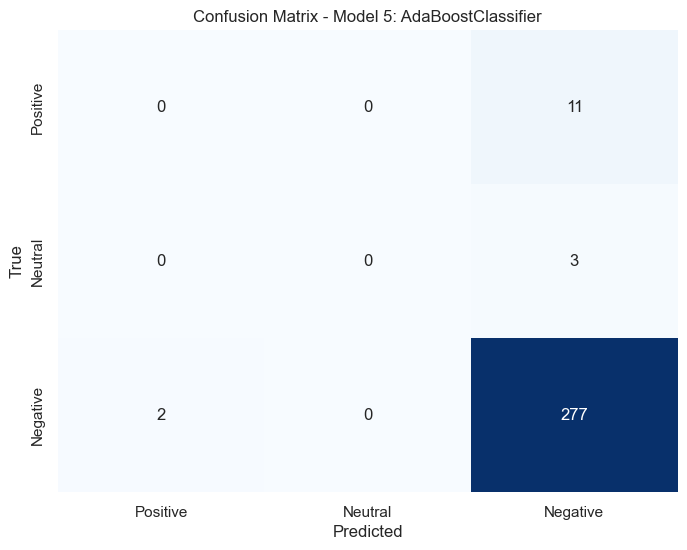

------------------
Model 6: XGBClassifier
Training Accuracy: 1.0
Testing Accuracy: 0.9522184300341296

Confusion matrix for Model 6: XGBClassifier 

 [[  0   0  11]
 [  1   0   2]
 [  0   0 279]]


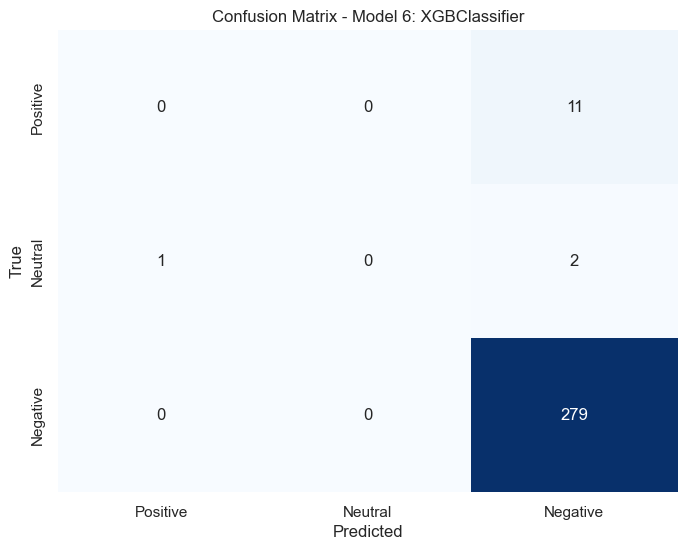

------------------
[LightGBM] [Warning] feature_fraction is set=0.9, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.9
[LightGBM] [Warning] bagging_fraction is set=0.9, subsample=1.0 will be ignored. Current value: bagging_fraction=0.9
[LightGBM] [Warning] bagging_freq is set=50, subsample_freq=0 will be ignored. Current value: bagging_freq=50
[LightGBM] [Warning] feature_fraction is set=0.9, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.9
[LightGBM] [Warning] bagging_fraction is set=0.9, subsample=1.0 will be ignored. Current value: bagging_fraction=0.9
[LightGBM] [Warning] bagging_freq is set=50, subsample_freq=0 will be ignored. Current value: bagging_freq=50
[LightGBM] [Info] This is the GPU trainer!!
[LightGBM] [Debug] Dataset::GetMultiBinFromSparseFeatures: sparse rate 0.938296
[LightGBM] [Info] Total Bins 32999
[LightGBM] [Info] Number of data points in the train set: 1172, number of used features: 1117
[LightGBM] [Info] Using GP

[LightGBM] [Debug] Trained a tree with leaves = 31 and depth = 10
[LightGBM] [Debug] Trained a tree with leaves = 31 and depth = 9
[LightGBM] [Debug] Trained a tree with leaves = 31 and depth = 12
[LightGBM] [Debug] Trained a tree with leaves = 31 and depth = 12
[LightGBM] [Debug] Trained a tree with leaves = 31 and depth = 9
[LightGBM] [Debug] Trained a tree with leaves = 31 and depth = 9
[LightGBM] [Debug] Trained a tree with leaves = 31 and depth = 11
[LightGBM] [Debug] Trained a tree with leaves = 31 and depth = 15
[LightGBM] [Debug] Trained a tree with leaves = 31 and depth = 8
[LightGBM] [Debug] Trained a tree with leaves = 31 and depth = 11
[LightGBM] [Debug] Trained a tree with leaves = 31 and depth = 11
[LightGBM] [Debug] Trained a tree with leaves = 31 and depth = 9
[LightGBM] [Debug] Trained a tree with leaves = 31 and depth = 11
[LightGBM] [Debug] Trained a tree with leaves = 31 and depth = 10
[LightGBM] [Debug] Trained a tree with leaves = 31 and depth = 8
[LightGBM] [Debu

[LightGBM] [Debug] Trained a tree with leaves = 31 and depth = 10
[LightGBM] [Debug] Trained a tree with leaves = 31 and depth = 14
[LightGBM] [Debug] Trained a tree with leaves = 31 and depth = 10
[LightGBM] [Debug] Trained a tree with leaves = 31 and depth = 10
[LightGBM] [Debug] Trained a tree with leaves = 31 and depth = 15
[LightGBM] [Debug] Trained a tree with leaves = 31 and depth = 9
[LightGBM] [Debug] Trained a tree with leaves = 31 and depth = 10
[LightGBM] [Debug] Trained a tree with leaves = 31 and depth = 15
[LightGBM] [Debug] Trained a tree with leaves = 31 and depth = 9
[LightGBM] [Debug] Trained a tree with leaves = 31 and depth = 9
[LightGBM] [Debug] Trained a tree with leaves = 31 and depth = 8
[LightGBM] [Debug] Trained a tree with leaves = 31 and depth = 8
[LightGBM] [Debug] Trained a tree with leaves = 31 and depth = 9
[LightGBM] [Debug] Trained a tree with leaves = 31 and depth = 10
[LightGBM] [Debug] Trained a tree with leaves = 31 and depth = 8
[LightGBM] [Debug

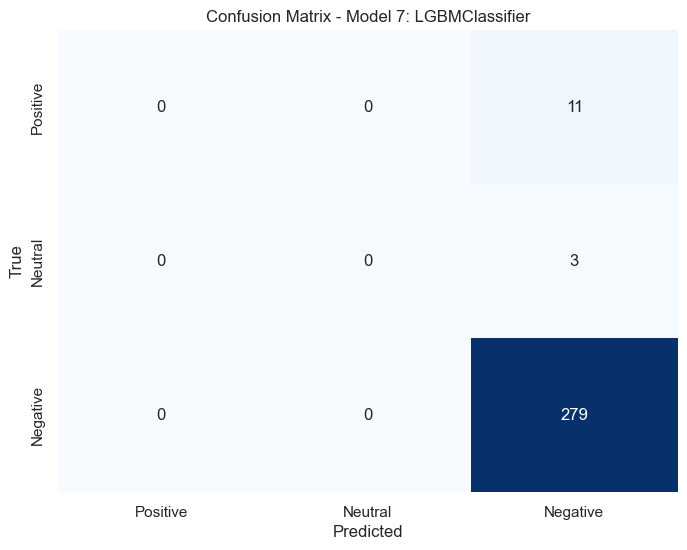

------------------
Model 8: KNeighborsClassifier
Training Accuracy: 0.9530716723549488
Testing Accuracy: 0.9522184300341296

Confusion matrix for Model 8: KNeighborsClassifier 

 [[  0   0  11]
 [  0   0   3]
 [  0   0 279]]


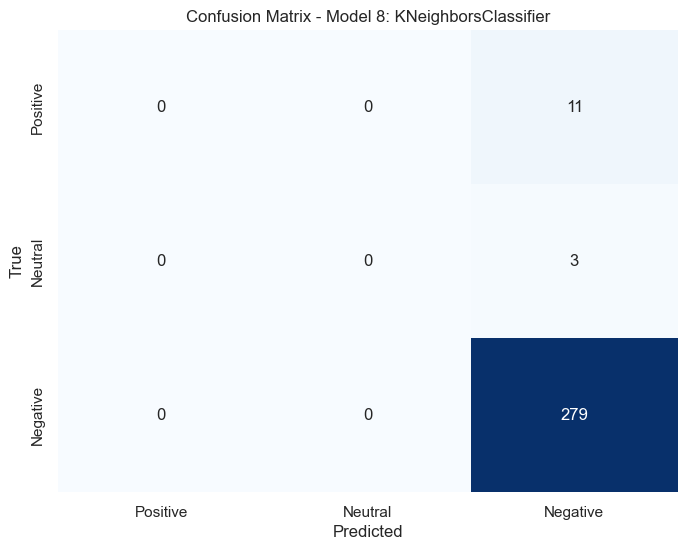

------------------
Model 9: GradientBoostingClassifier
Training Accuracy: 1.0
Testing Accuracy: 0.9419795221843004

Confusion matrix for Model 9: GradientBoostingClassifier 

 [[  0   0  11]
 [  0   0   3]
 [  1   2 276]]


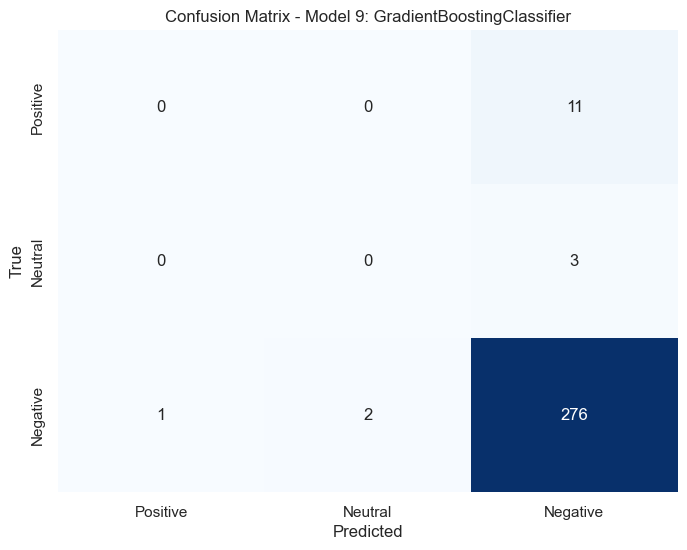

------------------


In [37]:
from sklearn.metrics import confusion_matrix,classification_report

# Define your sentiment labels
labels = ['Positive', 
          'Neutral', 
          'Negative']

# Convert your TF-IDF sparse matrix to a dense matrix for models that require dense input
X_train_dense = X_train.toarray()
X_test_dense = X_test.toarray()

# Evaluate each model
for i, model in enumerate(models):
    # Check if the model requires dense data (like GaussianNB)
    if isinstance(model, GaussianNB):
        model.fit(X_train_dense, y_train)
        y_train_pred = model.predict(X_train_dense)
        y_test_pred = model.predict(X_test_dense)
    else:
        model.fit(X_train, y_train)
        y_train_pred = model.predict(X_train)
        y_test_pred = model.predict(X_test)
    
    train_accuracy = accuracy_score(y_train, y_train_pred)
    test_accuracy = accuracy_score(y_test, y_test_pred)
    
    print(f"Model {i+1}: {type(model).__name__}")
    print(f"Training Accuracy: {train_accuracy}")
    print(f"Testing Accuracy: {test_accuracy}")
    print()

    # Calculate the confusion matrix
    cm = confusion_matrix(y_test, y_test_pred)
    
    print(f'Confusion matrix for Model {i+1}: {type(model).__name__} \n\n', cm)
    
    # Plot the confusion matrix with annotations for three classes
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False,
                xticklabels=labels, yticklabels=labels)
    
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.title(f"Confusion Matrix - Model {i+1}: {type(model).__name__}")
    plt.show()
    
    print("------------------")

In [39]:
import joblib
import os

# Create directory to store models
save_dir = r"C:\Users\rinka\Desktop\Recommendation\Sentiment_Models"
os.makedirs(save_dir, exist_ok=True)

In [40]:
# Define sentiment labels
sentiment_labels = ['Positive', 'Neutral', 'Negative']

# Convert sparse matrix to dense for models that require dense input
X_train_dense = X_train.toarray()
X_test_dense = X_test.toarray()

# Models to be evaluated
models = [
    GaussianNB(),
    DecisionTreeClassifier(random_state=42),
    KNeighborsClassifier(),
    RandomForestClassifier(n_estimators=100, random_state=42),
    LogisticRegression(random_state=42, max_iter=1000),
    AdaBoostClassifier(random_state=42),
    XGBClassifier(random_state=42),
    LGBMClassifier(),
    CatBoostClassifier(task_type='GPU', iterations=1000, learning_rate=0.1, depth=6, verbose=0, random_state=42)
]

# Evaluate each model
for i, model in enumerate(models):

    model_name = type(model).__name__
    print(f"Model {i+1}: {model_name}")

    # Train
    if isinstance(model, (GaussianNB, KNeighborsClassifier)):
        model.fit(X_train_dense, y_train)
        y_train_pred = model.predict(X_train_dense)
        y_test_pred = model.predict(X_test_dense)
    else:
        model.fit(X_train, y_train)
        y_train_pred = model.predict(X_train)
        y_test_pred = model.predict(X_test)

    # Accuracy
    train_accuracy = accuracy_score(y_train, y_train_pred)
    test_accuracy = accuracy_score(y_test, y_test_pred)

    print(f"Training Accuracy: {train_accuracy}")
    print(f"Testing Accuracy: {test_accuracy}")

    # Classification report
    report = classification_report(y_test, y_test_pred, target_names=sentiment_labels)
    print("\nClassification Report:")
    print(report)

    # Save model
    model_path = os.path.join(save_dir, f"{model_name}.pkl")
    joblib.dump(model, model_path)

    print(f"Model saved at: {model_path}")
    print("=======================================")

Model 1: GaussianNB
Training Accuracy: 0.9982935153583617
Testing Accuracy: 0.9488054607508533

Classification Report:
              precision    recall  f1-score   support

    Positive       0.00      0.00      0.00        11
     Neutral       0.00      0.00      0.00         3
    Negative       0.95      1.00      0.97       279

    accuracy                           0.95       293
   macro avg       0.32      0.33      0.32       293
weighted avg       0.91      0.95      0.93       293

Model saved at: C:\Users\rinka\Desktop\Recommendation\Sentiment_Models\GaussianNB.pkl
Model 2: DecisionTreeClassifier
Training Accuracy: 1.0
Testing Accuracy: 0.9146757679180887

Classification Report:
              precision    recall  f1-score   support

    Positive       0.14      0.18      0.16        11
     Neutral       0.00      0.00      0.00         3
    Negative       0.96      0.95      0.96       279

    accuracy                           0.91       293
   macro avg       0.37   

[LightGBM] [Debug] Trained a tree with leaves = 31 and depth = 9
[LightGBM] [Debug] Trained a tree with leaves = 31 and depth = 11
[LightGBM] [Debug] Trained a tree with leaves = 31 and depth = 13
[LightGBM] [Debug] Trained a tree with leaves = 31 and depth = 8
[LightGBM] [Debug] Trained a tree with leaves = 31 and depth = 10
[LightGBM] [Debug] Trained a tree with leaves = 31 and depth = 11
[LightGBM] [Debug] Trained a tree with leaves = 31 and depth = 8
[LightGBM] [Debug] Trained a tree with leaves = 31 and depth = 12
[LightGBM] [Debug] Trained a tree with leaves = 31 and depth = 10
[LightGBM] [Debug] Trained a tree with leaves = 31 and depth = 8
[LightGBM] [Debug] Trained a tree with leaves = 31 and depth = 12
[LightGBM] [Debug] Trained a tree with leaves = 31 and depth = 14
[LightGBM] [Debug] Trained a tree with leaves = 31 and depth = 9
[LightGBM] [Debug] Trained a tree with leaves = 31 and depth = 12
[LightGBM] [Debug] Trained a tree with leaves = 31 and depth = 12
[LightGBM] [Deb

[LightGBM] [Debug] Trained a tree with leaves = 31 and depth = 15
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Debug] Trained a tree with leaves = 12 and depth = 7
[LightGBM] [Debug] Trained a tree with leaves = 31 and depth = 13
[LightGBM] [Debug] Trained a tree with leaves = 31 and depth = 12
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Debug] Trained a tree with leaves = 13 and depth = 7
[LightGBM] [Debug] Trained a tree with leaves = 31 and depth = 14
[LightGBM] [Debug] Trained a tree with leaves = 31 and depth = 13
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Debug] Trained a tree with leaves = 13 and depth = 9
[LightGBM] [Debug] Trained a tree with leaves = 31 and depth = 14
[LightGBM] [Debug] Trained a tree with leaves = 31 and depth = 18
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Debug] Trained a tree with leav

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Debug] Trained a tree with leaves = 16 and depth = 9
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Debug] Trained a tree with leaves = 2 and depth = 1
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Debug] Trained a tree with leaves = 16 and depth = 9
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Debug] Trained a tree with leaves = 17 and depth = 12
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Debug] Trained a tree with leaves = 2 and depth = 1
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Debug] Trained a tree with leaves = 16 and depth = 9
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Debug] Trained a tree with leaves = 14 and depth = 10
[LightGBM] [Warning]

CatBoostError: catboost/cuda/cuda_lib/cuda_base.h:265: CUDA error 35: CUDA driver version is insufficient for CUDA runtime version

In [42]:
joblib.dump(tfidf_vectorizer, "saved_models/vectorizer.pkl")

['saved_models/vectorizer.pkl']